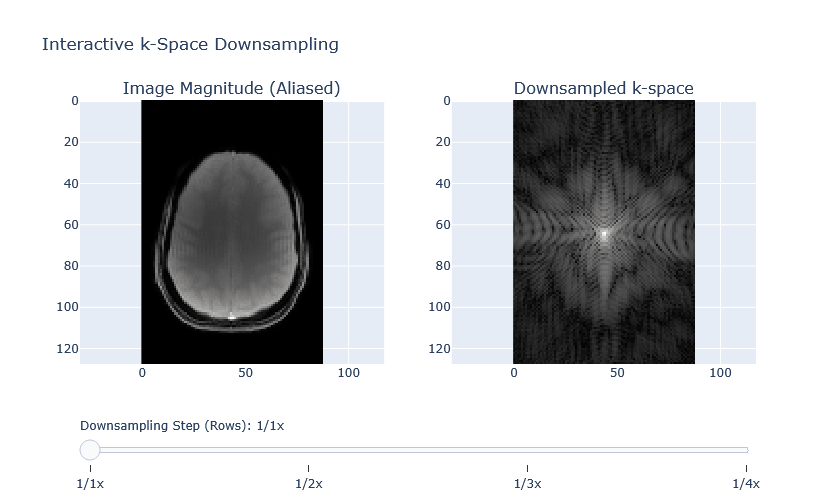

In [2]:
#| label: fig3

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Load the k-space data
k_space = np.load('kspace_combined.npy')
rows, cols = k_space.shape

# 2. Initialize Plotly subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=("Image Magnitude (Aliased)", "Downsampled k-space"))
frames = []
steps = []

# 3. Pre-calculate frames for different downsampling step sizes (1 = full, 2 = half, 3, 4)
# Step size corresponds to taking every n-th row
step_factors = [1, 2, 3, 4]

for i, sf in enumerate(step_factors):
    # Downsample k-space by taking every 'sf'-th row
    k_space_downsampled = k_space[::sf, :]
    
    # Transform back to image space
    img_downsampled = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k_space_downsampled)))
    img_mag = np.abs(img_downsampled)
    
    # Logarithmic transformation for k-space visualization
    k_space_log = np.log(np.abs(k_space_downsampled) + 1e-5)
    
    # Add initial traces (Frame 0, step factor = 1)
    if i == 0:
        fig.add_trace(go.Heatmap(z=img_mag, colorscale='gray', showscale=False), row=1, col=1)
        fig.add_trace(go.Heatmap(z=k_space_log, colorscale='gray', showscale=False), row=1, col=2)
        
    # Append frame for the current downsampling factor
    frames.append(go.Frame(data=[go.Heatmap(z=img_mag), go.Heatmap(z=k_space_log)], name=str(sf)))
    
    # Configure slider step
    step = dict(
        method="animate",
        args=[[str(sf)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}],
        label=f"1/{sf}x"
    )
    steps.append(step)

# 4. Apply layout, slider, and aspect ratio lock
fig.frames = frames
sliders = [dict(
    active=0,
    currentvalue={"prefix": "Downsampling Step (Rows): "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders, 
    height=500, 
    title="Interactive k-Space Downsampling",
    yaxis=dict(scaleanchor="x", autorange="reversed"),
    yaxis2=dict(scaleanchor="x2", autorange="reversed")
)

fig